# TFT — **Ablation (laptop-schonend): Wind und Geo**

Gleiche Fragestellung wie zuvor — *tragen **Windgeschwindigkeit** (`WSPM`), **Windrichtung** (`wd`)
und **Geo** (`lon`/`lat`) bei?* — aber **bewusst ressourcenschonend**, damit der Rechner nicht
einfriert. Fuenf Varianten desselben TFT, nur die Eingaben aendern sich:

| Variante | WSPM | wd | Geo |
|----------|:---:|:---:|:---:|
| **Basis** | – | – | – |
| **+ Windgeschw.** | ✓ | – | – |
| **+ Windrichtung** | – | ✓ | – |
| **+ beide Wind** | ✓ | ✓ | – |
| **+ beide Wind + Geo** | ✓ | ✓ | ✓ |

### Was hier schont (und warum)

- **Weniger Daten:** nur die letzten `USE_DAYS` Tage (Standard 540 ≈ 18 Monate) statt 4 Jahre.
  Das ist der groesste RAM-Hebel — genau daran ist der Rechner vorher volllgelaufen.
- **Kleineres Modell:** `hidden_size=16` (statt 32), 1 Attention-Head, `hidden_continuous_size=8`.
- **Kleinere Batch:** `batch_size=64`. **Kuerzere Sequenzen:** 24 h Rueckblick, 6 h Vorhersage.
- **Weniger Epochen:** `max_epochs=8`, EarlyStopping `patience=3`.
- **1 Seed** als Standard (`SEEDS=[42]`) → nur 5 Trainings. Mehr Seeds erst, wenn es stabil laeuft.
- **Speicher-Aufraeumer** nach jedem Lauf (`gc.collect()` + `torch.cuda.empty_cache()`), plus eine
  **RAM/VRAM-Anzeige**, damit du siehst, dass der Speicher wieder frei wird.

> **Waehrend es laeuft:** behalte den Windows-Task-Manager im Blick. Bleibt der RAM unter ~85 %,
> ist alles gut. Steigt er stetig Richtung 95 %, brich ab und sag mir Bescheid — dann verkleinern
> wir weiter (z. B. `USE_DAYS=365` oder nur die 3 Paper-Stationen).
>
> **Einordnung:** In allen Varianten kennt das Modell die Station als Kategorie; die Geo-Zeile misst
> den *zusaetzlichen* Nutzen der expliziten Koordinaten. Das Originalpaper (Zhang & Awang 2025) nutzt
> nur Windgeschwindigkeit — die `wd`-Varianten sind eine eigene Erweiterung.

## 1. Bibliotheken

In [1]:
%pip install psutil
import warnings
warnings.filterwarnings("ignore")

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

torch.set_float32_matmul_precision("medium")

def mem_info():
    "Kurze Speicheranzeige (VRAM + RAM), damit man das Freigeben sieht."
    txt = []
    if torch.cuda.is_available():
        txt.append(f"VRAM belegt: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    try:
        import psutil
        txt.append(f"RAM genutzt: {psutil.virtual_memory().percent:.0f}%")
    except Exception:
        pass
    return " | ".join(txt) if txt else "(keine Speicherinfo verfuegbar)"

print("torch:", torch.__version__, "| GPU:", torch.cuda.is_available())
print(mem_info())

Note: you may need to restart the kernel to use updated packages.
torch: 2.2.2+cu121 | GPU: True
VRAM belegt: 0.00 GB | RAM genutzt: 56%


## 2. Daten laden

In [2]:
import io, zipfile, urllib.request, os

DATA_DIR = "beijing_data"
UCI_URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
STATIONS = ["Aotizhongxin","Changping","Dingling","Dongsi","Guanyuan","Gucheng",
            "Huairou","Nongzhanguan","Shunyi","Tiantan","Wanliu","Wanshouxigong"]

def try_download():
    try:
        print("Lade UCI-Datensatz ...")
        rawb = urllib.request.urlopen(UCI_URL, timeout=30).read()
        z = zipfile.ZipFile(io.BytesIO(rawb)); os.makedirs(DATA_DIR, exist_ok=True)
        for name in z.namelist():
            if name.endswith(".zip"):
                zipfile.ZipFile(io.BytesIO(z.read(name))).extractall(DATA_DIR)
            elif name.endswith(".csv"):
                z.extract(name, DATA_DIR)
        print("Download OK."); return True
    except Exception as e:
        print("Download fehlgeschlagen:", e); return False

def load_csvs():
    import glob
    files = glob.glob(os.path.join(DATA_DIR, "**", "PRSA_Data_*.csv"), recursive=True)
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True) if len(files) >= 12 else None

def make_synthetic():
    print(">>> SYNTHETISCHE Demo-Daten <<<")
    rng = np.random.default_rng(0); frames = []
    hours = pd.date_range("2013-03-01", periods=24*60, freq="h")
    for st in STATIONS:
        n=len(hours); daily=30*np.sin(2*np.pi*hours.hour/24)
        frames.append(pd.DataFrame({"year":hours.year,"month":hours.month,"day":hours.day,"hour":hours.hour,
            "PM2.5":(80+daily+rng.normal(0,15,n)).clip(1),"PM10":(100+daily+rng.normal(0,20,n)).clip(1),
            "SO2":rng.normal(15,5,n).clip(0),"NO2":rng.normal(50,15,n).clip(0),"O3":rng.normal(60,20,n).clip(0),
            "TEMP":13+rng.normal(0,2,n),"DEWP":rng.normal(2,5,n),"RAIN":0.0,
            "wd":rng.choice(["N","NE","E","SE","S","SW","W","NW"],n),"WSPM":rng.normal(2,1,n).clip(0),"station":st}))
    return pd.concat(frames, ignore_index=True)

raw = load_csvs() if try_download() else None
if raw is None:
    raw = make_synthetic()
print("Roh-Datensatz:", raw.shape)

Lade UCI-Datensatz ...
Download OK.
Roh-Datensatz: (420768, 18)


## 3. Vorverarbeitung + **Datenmenge reduzieren** + Koordinaten

`USE_DAYS` schneidet auf die letzten Monate zu — der wichtigste Speicher-Hebel. Danach wird
`raw` geloescht und Speicher freigegeben.

In [3]:
USE_DAYS = 540   # nur die letzten ~18 Monate nutzen (kleiner = schonender). 365 = 1 Jahr, 730 = 2 Jahre.

df = raw.copy()
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])

# --- Datenmenge reduzieren: nur die letzten USE_DAYS Tage ---
cutoff_date = df["datetime"].max() - pd.Timedelta(days=USE_DAYS)
df = df[df["datetime"] >= cutoff_date].copy()

df = df.sort_values(["station","datetime"]).reset_index(drop=True)
df["time_idx"] = ((df["datetime"] - df["datetime"].min()).dt.total_seconds() // 3600).astype(int)
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["wd"] = df["wd"].astype(str).replace("nan","unknown").fillna("unknown")

num_cols = [c for c in ["PM2.5","PM10","SO2","NO2","O3","TEMP","DEWP","RAIN","WSPM"] if c in df.columns]
df[num_cols] = (df.groupby("station")[num_cols].apply(lambda g: g.ffill().bfill()).reset_index(level=0, drop=True))
df[num_cols] = df[num_cols].fillna(0)

df = df.rename(columns={"PM2.5": "PM25"})

coord_df = pd.read_csv(os.path.join("..", "data", "stations_geo.csv"))[["station","lon","lat"]]
df = df.merge(coord_df, on="station", how="left")
for c in ["lon","lat"]:
    lo, hi = df[c].min(), df[c].max()
    df[c+"_norm"] = (df[c] - lo) / (hi - lo + 1e-9)
assert df[["lon_norm","lat_norm"]].isna().sum().sum() == 0

# Rohdaten freigeben
del raw
gc.collect()

print(f"Genutzter Zeitraum: letzte {USE_DAYS} Tage | Zeilen: {len(df):,} | Stationen: {df['station'].nunique()}")
print(mem_info())

Genutzter Zeitraum: letzte 540 Tage | Zeilen: 155,532 | Stationen: 12
VRAM belegt: 0.00 GB | RAM genutzt: 56%


## 4. Kleine, schonende Trainings-/Test-Funktion

Kleines Modell, kurze Sequenzen, kleine Batch. Nach jedem Lauf wird aufgeraeumt.

In [4]:
max_encoder_length    = 24   # 1 Tag Rueckblick (statt 48) -> weniger Speicher
max_prediction_length = 6    # 6 h Vorhersage (statt 12)
target = "PM25"

test_days = 14
training_cutoff = df["time_idx"].max() - test_days * 24

REALS_BASE = ["PM25", "PM10", "SO2", "NO2", "O3", "TEMP", "DEWP", "RAIN"]

def train_variante(use_wspm, use_wd, use_geo, label, seed, max_epochs=8):
    pl.seed_everything(seed)

    unknown_reals = REALS_BASE + (["WSPM"] if use_wspm else [])
    unknown_cats  = ["wd"] if use_wd else []
    static_reals  = ["lon_norm", "lat_norm"] if use_geo else []

    training = TimeSeriesDataSet(
        df[df["time_idx"] <= training_cutoff],
        time_idx="time_idx", target=target, group_ids=["station"],
        max_encoder_length=max_encoder_length, max_prediction_length=max_prediction_length,
        static_categoricals=["station"],
        static_reals=static_reals,
        time_varying_known_reals=["time_idx", "hour", "dayofweek"],
        time_varying_unknown_reals=unknown_reals,
        time_varying_unknown_categoricals=unknown_cats,
        target_normalizer=GroupNormalizer(groups=["station"]),
        add_relative_time_idx=True, add_target_scales=True,
        add_encoder_length=True, allow_missing_timesteps=True,
    )
    test = TimeSeriesDataSet.from_dataset(training, df,
                                          min_prediction_idx=training_cutoff + 1, stop_randomization=True)

    tl    = training.to_dataloader(train=True,  batch_size=64, num_workers=0)   # kleine Batch
    testl = test.to_dataloader(train=False, batch_size=128, num_workers=0)

    model = TemporalFusionTransformer.from_dataset(
        training, learning_rate=0.03,
        hidden_size=16, attention_head_size=1, dropout=0.1, hidden_continuous_size=8,
        loss=QuantileLoss(), optimizer="adam", reduce_on_plateau_patience=2,
    )
    ckpt = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)
    trainer = pl.Trainer(
        max_epochs=max_epochs, accelerator="auto", devices=1, gradient_clip_val=0.1,
        callbacks=[EarlyStopping("val_loss", patience=3, mode="min"), ckpt],
        enable_progress_bar=True, enable_model_summary=False, logger=False,
    )
    trainer.fit(model, train_dataloaders=tl, val_dataloaders=testl)
    best = TemporalFusionTransformer.load_from_checkpoint(ckpt.best_model_path) if ckpt.best_model_path else model

    p = best.predict(testl, mode="prediction", return_y=True)
    a = p.output.detach().cpu().numpy().reshape(-1)
    b = p.y[0].detach().cpu().numpy().reshape(-1)
    mae  = float(np.mean(np.abs(a - b)))
    rmse = float(np.sqrt(np.mean((a - b) ** 2)))
    result = {"Variante": label, "seed": seed, "MAE": mae, "RMSE": rmse}
    print(f"    -> {label:20s} | seed {seed}: MAE = {mae:.3f} | RMSE = {rmse:.3f}")

    # --- Speicher freigeben ---
    del model, best, trainer, training, test, tl, testl, p, a, b, ckpt
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("    Speicher nach Aufraeumen:", mem_info())

    return result

## 5. Varianten trainieren (Standard: 1 Seed = 5 Trainings)

`SEEDS=[42]` = nur 5 Laeufe. Erst wenn das **stabil** durchlaeuft und der RAM im Task-Manager
nicht kritisch wird, kannst du auf `[42, 43]` gehen. Notfalls einzelne Zeilen in `configs` auskommentieren.

In [5]:
SEEDS = [42, 43]   # laptop-schonend: 1 Seed. Fuer eine Streuung spaeter [42, 43].

configs = [
    dict(label="Basis",              wspm=False, wd=False, geo=False),
    dict(label="+ Windgeschw.",      wspm=True,  wd=False, geo=False),
    dict(label="+ Windrichtung",     wspm=False, wd=True,  geo=False),
    dict(label="+ beide Wind",       wspm=True,  wd=True,  geo=False),
    dict(label="+ beide Wind + Geo", wspm=True,  wd=True,  geo=True),
]

total = len(SEEDS) * len(configs)
alle = []
i = 0
for seed in SEEDS:
    for c in configs:
        i += 1
        print(f"\n########## Lauf {i}/{total}: {c['label']} | seed {seed} — startet ##########")
        alle.append(train_variante(c["wspm"], c["wd"], c["geo"], c["label"], seed=seed))

res_all = pd.DataFrame(alle)
print("\nAlle Einzellaeufe fertig:")
print(res_all.round(3).to_string(index=False))

Seed set to 42



########## Lauf 1/10: Basis | seed 42 — startet ##########


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

`Trainer.fit` stopped: `max_epochs=8` reached.


...

    -> + beide Wind         | seed 43: MAE = 18.405 | RMSE = 33.708
    Speicher nach Aufraeumen: VRAM belegt: 0.00 GB | RAM genutzt: 50%

########## Lauf 10/10: + beide Wind + Geo | seed 43 — startet ##########


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


    -> + beide Wind + Geo   | seed 43: MAE = 18.875 | RMSE = 33.291
    Speicher nach Aufraeumen: VRAM belegt: 0.00 GB | RAM genutzt: 50%

Alle Einzellaeufe fertig:
          Variante  seed    MAE   RMSE
             Basis    42 20.319 38.223
     + Windgeschw.    42 18.792 34.251
    + Windrichtung    42 18.253 35.794
      + beide Wind    42 18.705 32.160
+ beide Wind + Geo    42 18.968 34.477
             Basis    43 18.478 37.269
     + Windgeschw.    43 18.271 34.228
    + Windrichtung    43 18.711 35.660
      + beide Wind    43 18.405 33.708
+ beide Wind + Geo    43 18.875 33.291


## 6. Aggregation (Mittelwert ± Std.-Abw., falls mehrere Seeds)

In [6]:
order = [c["label"] for c in configs]
res = (res_all.groupby("Variante")
              .agg(MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
                   RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
                   n_Seeds=("MAE", "size"))
              .reindex(order).reset_index())

print(f"Ueber {res['n_Seeds'].iloc[0]} Seed(s) (MAE/RMSE in ug/m3):\n")
print(res.round(3).to_string(index=False))

res_all.round(4).to_csv(os.path.join("..", "data", "ergebnis_ablation_leicht_alle.csv"), index=False)
res.round(4).to_csv(os.path.join("..", "data", "ergebnis_ablation_leicht_aggregiert.csv"), index=False)
print("\nGespeichert: ergebnis_ablation_leicht_alle.csv und ergebnis_ablation_leicht_aggregiert.csv")

Ueber 2 Seed(s) (MAE/RMSE in ug/m3):

          Variante  MAE_mean  MAE_std  RMSE_mean  RMSE_std  n_Seeds
             Basis    19.398    1.302     37.746     0.674        2
     + Windgeschw.    18.532    0.368     34.240     0.016        2
    + Windrichtung    18.482    0.324     35.727     0.095        2
      + beide Wind    18.555    0.212     32.934     1.095        2
+ beide Wind + Geo    18.922    0.065     33.884     0.839        2

Gespeichert: ergebnis_ablation_leicht_alle.csv und ergebnis_ablation_leicht_aggregiert.csv


## 7. Auswertung: Welche Wind-Variable hilft, und traegt Geo bei?

MAE Basis              : 19.398
MAE + Windgeschw.      : 18.532
MAE + Windrichtung     : 18.482
MAE + beide Wind       : 18.555
MAE + beide Wind + Geo : 18.922

Windgeschw.-Effekt (Basis->+WSPM)     : +0.867 ug/m3  (+4.47 %)
Windrichtungs-Effekt (Basis->+wd)     : +0.916 ug/m3  (+4.72 %)
Geo-Effekt (+beide Wind->+Geo)        : -0.367 ug/m3  (-1.98 %)

=> Bessere Wind-Variable: Windrichtung (18.48 vs 18.53 MAE).


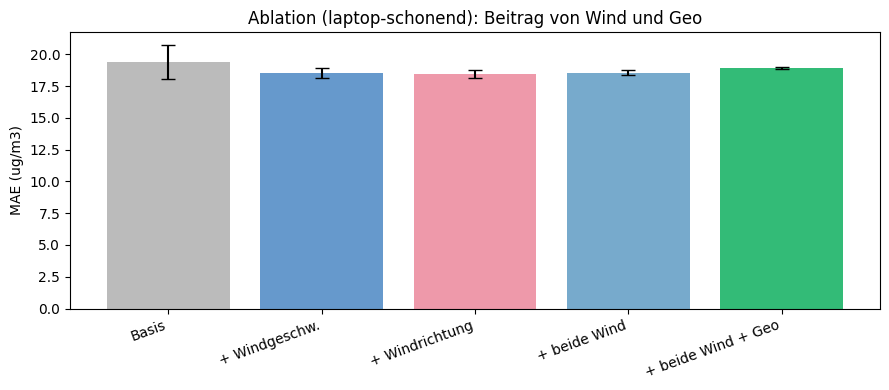

In [7]:
def m(label):
    return float(res.loc[res["Variante"] == label, "MAE_mean"].iloc[0])
def s(label):
    v = res.loc[res["Variante"] == label, "MAE_std"].iloc[0]
    return float(v) if pd.notna(v) else 0.0

m_basis, m_ws, m_wr = m("Basis"), m("+ Windgeschw."), m("+ Windrichtung")
m_bw, m_full        = m("+ beide Wind"), m("+ beide Wind + Geo")

def zeile(name, basis, neu):
    delta = basis - neu
    pct = 100 * delta / basis if basis else float("nan")
    print(f"{name:38s}: {delta:+.3f} ug/m3  ({pct:+.2f} %)")

print(f"MAE Basis              : {m_basis:.3f}")
print(f"MAE + Windgeschw.      : {m_ws:.3f}")
print(f"MAE + Windrichtung     : {m_wr:.3f}")
print(f"MAE + beide Wind       : {m_bw:.3f}")
print(f"MAE + beide Wind + Geo : {m_full:.3f}\n")

zeile("Windgeschw.-Effekt (Basis->+WSPM)",   m_basis, m_ws)
zeile("Windrichtungs-Effekt (Basis->+wd)",   m_basis, m_wr)
zeile("Geo-Effekt (+beide Wind->+Geo)",      m_bw,    m_full)

print()
besser = "Windgeschwindigkeit" if m_ws < m_wr else "Windrichtung"
print(f"=> Bessere Wind-Variable: {besser} ({min(m_ws,m_wr):.2f} vs {max(m_ws,m_wr):.2f} MAE).")
if res["n_Seeds"].iloc[0] < 2:
    print("   Hinweis: nur 1 Seed -> keine Streuung. Fuer eine belastbare Aussage spaeter [42, 43] nutzen.")

# Balkendiagramm (Fehlerbalken nur wenn mehrere Seeds)
yerr = res["MAE_std"] if res["n_Seeds"].iloc[0] > 1 else None
plt.figure(figsize=(9, 4))
plt.bar(res["Variante"], res["MAE_mean"], yerr=yerr, capsize=5,
        color=["#bbb","#69c","#e9a","#7ac","#3b7"])
plt.ylabel("MAE (ug/m3)")
plt.title("Ablation (laptop-schonend): Beitrag von Wind und Geo")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()